<a href="https://colab.research.google.com/github/AbhaySingh71/Deep-Learning-for-Data-Science/blob/main/CNN%20Practice/research_paper_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# =============================
# PARAMETERS (Research Paper)
# =============================
IMG_SIZE = 48
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 100
WEIGHT_DECAY = 1e-4
LEARNING_RATE = 0.01

TRAIN_DIR = "/kaggle/input/datasets/msambare/fer2013/train"
TEST_DIR  = "//kaggle/input/datasets/msambare/fer2013/test"

# =============================
# LOAD TRAIN FILE PATHS
# =============================
all_files = []
all_labels = []

classes = sorted(os.listdir(TRAIN_DIR))

for label, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    for file in os.listdir(class_path):
        all_files.append(os.path.join(class_path, file))
        all_labels.append(label)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

# =============================
# SPLIT TRAIN INTO TRAIN + VAL
# =============================
X_train, X_val, y_train, y_val = train_test_split(
    all_files, all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=42
)

train_df = pd.DataFrame({"filename": X_train, "class": y_train})
val_df   = pd.DataFrame({"filename": X_val, "class": y_val})

# =============================
# DATA AUGMENTATION (Paper Style)
# =============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

# =============================
# TEST GENERATOR (Official Test)
# =============================
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =============================
# PRETRAINED VGG16
# =============================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

# =============================
# CLASSIFIER HEAD
# =============================
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# =============================
# OPTIMIZER (Best from Paper)
# =============================
optimizer = SGD(
    learning_rate=LEARNING_RATE,
    momentum=0.9,
    nesterov=True
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =============================
# CALLBACKS
# =============================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.75,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_pretrained_vgg16.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# =============================
# TRAIN (Frozen)
# =============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# =============================
# FINE TUNING
# =============================
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# =============================
# TEST EVALUATION
# =============================
test_loss, test_acc = model.evaluate(test_generator)

results = pd.DataFrame([{
    "Best_Validation_Accuracy": max(history.history["val_accuracy"]),
    "Final_Test_Accuracy": test_acc
}])

results.to_csv("final_best_results.csv", index=False)

print("Training complete on Kaggle FER2013.")

Found 22967 validated image filenames.
Found 5742 validated image filenames.
Found 7178 images belonging to 7 classes.


I0000 00:00:1771991051.893034      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


...

359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.3231 - loss: 1.7331 - val_accuracy: 0.3736 - val_loss: 1.6541 - learning_rate: 0.0100
Epoch 11/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3277 - loss: 1.7304
Epoch 11: val_accuracy did not improve from 0.37356
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.3277 - loss: 1.7304 - val_accuracy: 0.3560 - val_loss: 1.6640 - learning_rate: 0.0100
Epoch 12/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3294 - loss: 1.7284
Epoch 12: val_accuracy improved from 0.37356 to 0.37670, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.3294 - loss: 1.7284 - val_accuracy: 0.3767 - val_loss: 1.6441 - learning_rate: 0.0100
Epoch 13/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3247 - loss: 1.7319
Epoch 13: val_accuracy did not improve from 0.37670
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.3247 - loss: 1.7319 - val_accuracy: 0.3603 - val_loss: 1.6531 - learning_rate: 0.0100
Epoch 14/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3376 - loss: 1.7239
Epoch 14: val_accuracy improved from 0.37670 to 0.38314, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.3375 - loss: 1.7239 - val_accuracy: 0.3831 - val_loss: 1.6382 - learning_rate: 0.0100
Epoch 15/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3276 - loss: 1.7237
Epoch 15: val_accuracy did not improve from 0.38314
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.3276 - loss: 1.7237 - val_accuracy: 0.3743 - val_loss: 1.6382 - learning_rate: 0.0100
Epoch 16/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3254 - loss: 1.7289
Epoch 16: val_accuracy did not improve from 0.38314
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.3254 - loss: 1.7289 - val_accuracy: 0.3582 - val_loss: 1.6472 - learning_rate: 0.0100
Epoch 17/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3335 - loss: 1.7175
Epoch 17: val_accuracy did not improve from 0.38314
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.3335 - loss: 1.7175 - val_accuracy: 0.3736 - val_loss: 1.6362 - learning_rate: 0.010

359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.3456 - loss: 1.6821 - val_accuracy: 0.3863 - val_loss: 1.6064 - learning_rate: 0.0056
Epoch 30/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3506 - loss: 1.6815
Epoch 30: val_accuracy did not improve from 0.38628
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.3506 - loss: 1.6816 - val_accuracy: 0.3856 - val_loss: 1.6127 - learning_rate: 0.0056
Epoch 31/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3454 - loss: 1.6830
Epoch 31: val_accuracy did not improve from 0.38628
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.3455 - loss: 1.6830 - val_accuracy: 0.3736 - val_loss: 1.6217 - learning_rate: 0.0056
Epoch 32/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3503 - loss: 1.6794
Epoch 32: val_accuracy improved from 0.38628 to 0.38854, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.3503 - loss: 1.6794 - val_accuracy: 0.3885 - val_loss: 1.6081 - learning_rate: 0.0056
Epoch 33/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3505 - loss: 1.6774
Epoch 33: val_accuracy did not improve from 0.38854
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.3505 - loss: 1.6774 - val_accuracy: 0.3858 - val_loss: 1.6112 - learning_rate: 0.0056
Epoch 34/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3469 - loss: 1.6847
Epoch 34: val_accuracy did not improve from 0.38854
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.3469 - loss: 1.6847 - val_accuracy: 0.3851 - val_loss: 1.6065 - learning_rate: 0.0056
Epoch 35/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3525 - loss: 1.6791
Epoch 35: val_accuracy did not improve from 0.38854
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.3525 - loss: 1.6791 - val_accuracy: 0.3790 - val_loss: 1.6139 - learning_rate: 0.005

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# =============================
# PARAMETERS
# =============================
IMG_SIZE = 40   # paper used 40x40 crops
NUM_CLASSES = 7
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64
EPOCHS = 300

TRAIN_DIR = "/kaggle/input/datasets/msambare/fer2013/train"
TEST_DIR  = "/kaggle/input/datasets/msambare/fer2013/test"

# =============================
# LOAD FILES
# =============================
all_files, all_labels = [], []
classes = sorted(os.listdir(TRAIN_DIR))

for label, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    for file in os.listdir(class_path):
        all_files.append(os.path.join(class_path, file))
        all_labels.append(label)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

X_train, X_val, y_train, y_val = train_test_split(
    all_files, all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

train_df = pd.DataFrame({"filename": X_train, "class": y_train})
val_df   = pd.DataFrame({"filename": X_val, "class": y_val})

# =============================
# DATA AUGMENTATION
# =============================
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(48,48),   # keep original size for cropping
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=1,
    shuffle=False
)

# =============================
# VGGNet (Paper Variant)
# =============================
def build_vggnet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    model = models.Sequential()

    # Conv Block 1
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    # Conv Block 2
    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    # Conv Block 3
    model.add(layers.Conv2D(256, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(256, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    # Conv Block 4
    model.add(layers.Conv2D(512, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Conv2D(512, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu',
                           kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(WEIGHT_DECAY)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    return model

model = build_vggnet()

# =============================
# TRAINING
# =============================
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

reduce_lr = ReduceLROnPlateau(monitor="val_accuracy", factor=0.75, patience=5, verbose=1)
checkpoint = ModelCheckpoint("best_vggnet.h5", monitor="val_accuracy", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=EPOCHS,
                    callbacks=[reduce_lr, checkpoint, early_stop])

# =============================
# FINE-TUNING
# =============================
model.load_weights("best_vggnet.h5")
fine_tune_optimizer = SGD(learning_rate=1e-4, momentum=0.9, nesterov=True)
model.compile(optimizer=fine_tune_optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_ft = model.fit(train_generator,
                       validation_data=val_generator,
                       epochs=50,
                       callbacks=[reduce_lr, checkpoint])

# =============================
# TEN-CROP EVALUATION
# =============================
def ten_crop(img, crop_size=40):
    h, w = img.shape[:2]
    crops = []
    coords = [
        (0, 0),
        (0, w - crop_size),
        (h - crop_size, 0),
        (h - crop_size, w - crop_size),
        ((h - crop_size)//2, (w - crop_size)//2)
    ]
    for y, x in coords:
        crop = img[y:y+crop_size, x:x+crop_size]
        crops.append(crop)
        crops.append(np.fliplr(crop))
    return np.array(crops)

def predict_with_ten_crop(model, img_path, crop_size=40):
    img = image.load_img(img_path, color_mode="grayscale", target_size=(48,48))
    img = image.img_to_array(img).astype("float32") / 255.0
    crops = ten_crop(img, crop_size)
    crops = np.expand_dims(crops, axis=-1)
    preds = model.predict(crops, verbose=0)
    avg_pred = np.mean(preds, axis=0)
    return np.argmax(avg_pred), avg_pred

y_true, y_pred = [], []
for img_path, label in zip(test_generator.filepaths, test_generator.classes):
    pred_class, _ = predict_with_ten_crop(model, img_path)
    y_true.append(label)
    y_pred.append(pred_class)

# =============================
# RESULTS
# =============================
acc = np.mean(np.array(y_true) == np.array(y_pred))
print("Final Ten-Crop Test Accuracy:", acc)

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

Found 22967 validated image filenames.
Found 5742 validated image filenames.
Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2235 - loss: 2.2949
Epoch 1: val_accuracy improved from -inf to 0.25131, saving model to best_vggnet.h5


...

359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.6624 - loss: 1.1388 - val_accuracy: 0.6376 - val_loss: 1.1977 - learning_rate: 1.0000e-04
Epoch 11/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6607 - loss: 1.1411
Epoch 11: val_accuracy did not improve from 0.63758
359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.6607 - loss: 1.1411 - val_accuracy: 0.6369 - val_loss: 1.1980 - learning_rate: 1.0000e-04
Epoch 12/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6591 - loss: 1.1444
Epoch 12: val_accuracy did not improve from 0.63758
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.6591 - loss: 1.1444 - val_accuracy: 0.6357 - val_loss: 1.1982 - learning_rate: 1.0000e-04
Epoch 13/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6572 - loss: 1.1471
Epoch 13: val_accuracy improved from 0.63758 to 0.63932, saving model to best_vggnet.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.6572 - loss: 1.1471 - val_accuracy: 0.6393 - val_loss: 1.1953 - learning_rate: 1.0000e-04
Epoch 14/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6553 - loss: 1.1510
Epoch 14: val_accuracy did not improve from 0.63932
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.6553 - loss: 1.1510 - val_accuracy: 0.6358 - val_loss: 1.1987 - learning_rate: 1.0000e-04
Epoch 15/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6655 - loss: 1.1309
Epoch 15: val_accuracy did not improve from 0.63932
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.6655 - loss: 1.1309 - val_accuracy: 0.6360 - val_loss: 1.1989 - learning_rate: 1.0000e-04
Epoch 16/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6627 - loss: 1.1362
Epoch 16: val_accuracy did not improve from 0.63932
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.6627 - loss: 1.1362 - val_accuracy: 0.6360 - val_loss: 1.1961 - learning_rate: 1.0

359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.6624 - loss: 1.1234 - val_accuracy: 0.6407 - val_loss: 1.1931 - learning_rate: 4.2188e-05
Epoch 30/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6639 - loss: 1.1302
Epoch 30: val_accuracy did not improve from 0.64072
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.6639 - loss: 1.1302 - val_accuracy: 0.6383 - val_loss: 1.1950 - learning_rate: 4.2188e-05
Epoch 31/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6711 - loss: 1.1141
Epoch 31: val_accuracy improved from 0.64072 to 0.64089, saving model to best_vggnet.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.6711 - loss: 1.1141 - val_accuracy: 0.6409 - val_loss: 1.1925 - learning_rate: 4.2188e-05
Epoch 32/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6640 - loss: 1.1263
Epoch 32: val_accuracy did not improve from 0.64089
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.6640 - loss: 1.1263 - val_accuracy: 0.6381 - val_loss: 1.1935 - learning_rate: 4.2188e-05
Epoch 33/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6650 - loss: 1.1347
Epoch 33: val_accuracy did not improve from 0.64089
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.6650 - loss: 1.1346 - val_accuracy: 0.6393 - val_loss: 1.1937 - learning_rate: 4.2188e-05
Epoch 34/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6668 - loss: 1.1164
Epoch 34: val_accuracy did not improve from 0.64089
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.6668 - loss: 1.1164 - val_accuracy: 0.6385 - val_loss: 1.1928 - learning_rate: 4.2

359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.6634 - loss: 1.1271 - val_accuracy: 0.6411 - val_loss: 1.1935 - learning_rate: 3.1641e-05
Epoch 39/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6710 - loss: 1.1250
Epoch 39: val_accuracy did not improve from 0.64107
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.6709 - loss: 1.1250 - val_accuracy: 0.6395 - val_loss: 1.1933 - learning_rate: 3.1641e-05
Epoch 40/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6666 - loss: 1.1273
Epoch 40: val_accuracy did not improve from 0.64107
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.6666 - loss: 1.1273 - val_accuracy: 0.6395 - val_loss: 1.1945 - learning_rate: 3.1641e-05
Epoch 41/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6668 - loss: 1.1225
Epoch 41: val_accuracy did not improve from 0.64107
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.6668 - loss: 1.1225 - val_accuracy: 0.6383 - val_loss: 1.1927 - learning_rate: 3.1

# Abhay Builds

In [1]:
%%writefile kaggle.json
{
  "username": "ezatom",
  "key": "KGAT_164629"
}


Writing kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!pip install kaggle
!kaggle datasets list | head


ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset               Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           6449        127  1.0              
amar5693/student-performance-dataset                                 Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           5573         90  1.0              
algozee/heart-decices                                                Heart Disease Prediction Using Machine Learning       10070453  2026-02-22 17:32:58.757000            816      

In [4]:
!kaggle datasets download -d msambare/fer2013


Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
 90% 54.0M/60.3M [00:00<00:00, 565MB/s]
100% 60.3M/60.3M [00:00<00:00, 563MB/s]


In [5]:
!unzip fer2013.zip -d fer2013
!ls fer2013

Streaming output truncated to the last 5000 lines.
  inflating: fer2013/train/sad/Training_65267116.jpg  
  inflating: fer2013/train/sad/Training_65275626.jpg  
  inflating: fer2013/train/sad/Training_6529266.jpg  
  inflating: fer2013/train/sad/Training_65329617.jpg  
  inflating: fer2013/train/sad/Training_65338712.jpg  
  inflating: fer2013/train/sad/Training_65338797.jpg  
  inflating: fer2013/train/sad/Training_65387162.jpg  
  inflating: fer2013/train/sad/Training_65404494.jpg  
  inflating: fer2013/train/sad/Training_65426218.jpg  
  inflating: fer2013/train/sad/Training_65430136.jpg  
  inflating: fer2013/train/sad/Training_65437377.jpg  
  inflating: fer2013/train/sad/Training_6545735.jpg  
  inflating: fer2013/train/sad/Training_65463385.jpg  
  inflating: fer2013/train/sad/Training_65473985.jpg  
  inflating: fer2013/train/sad/Training_65502829.jpg  
  inflating: fer2013/train/sad/Training_65505359.jpg  
  inflating: fer2013/train/sad/Training_65508578.jpg  
  inflating: fer

In [21]:
print("Class distribution in Training Set:")
display(train_df['class'].value_counts().sort_index())

Class distribution in Training Set:


,count
class,
0,3196
1,349
2,3277
3,5772
4,3972
5,3864
6,2537


In [22]:
print("\nClass distribution in Validation Set:")
display(val_df['class'].value_counts().sort_index())


Class distribution in Validation Set:


,count
class,
0,799
1,87
2,820
3,1443
4,993
5,966
6,634


In [23]:
print("\nClass distribution in Test Set:")
class_labels = list(test_generator.class_indices.keys())
class_counts = pd.Series(test_generator.classes).value_counts().sort_index()
class_counts.index = class_labels # Map numerical labels to class names
display(class_counts)


Class distribution in Test Set:


,count
angry,958
disgust,111
fear,1024
happy,1774
neutral,1233
sad,1247
surprise,831


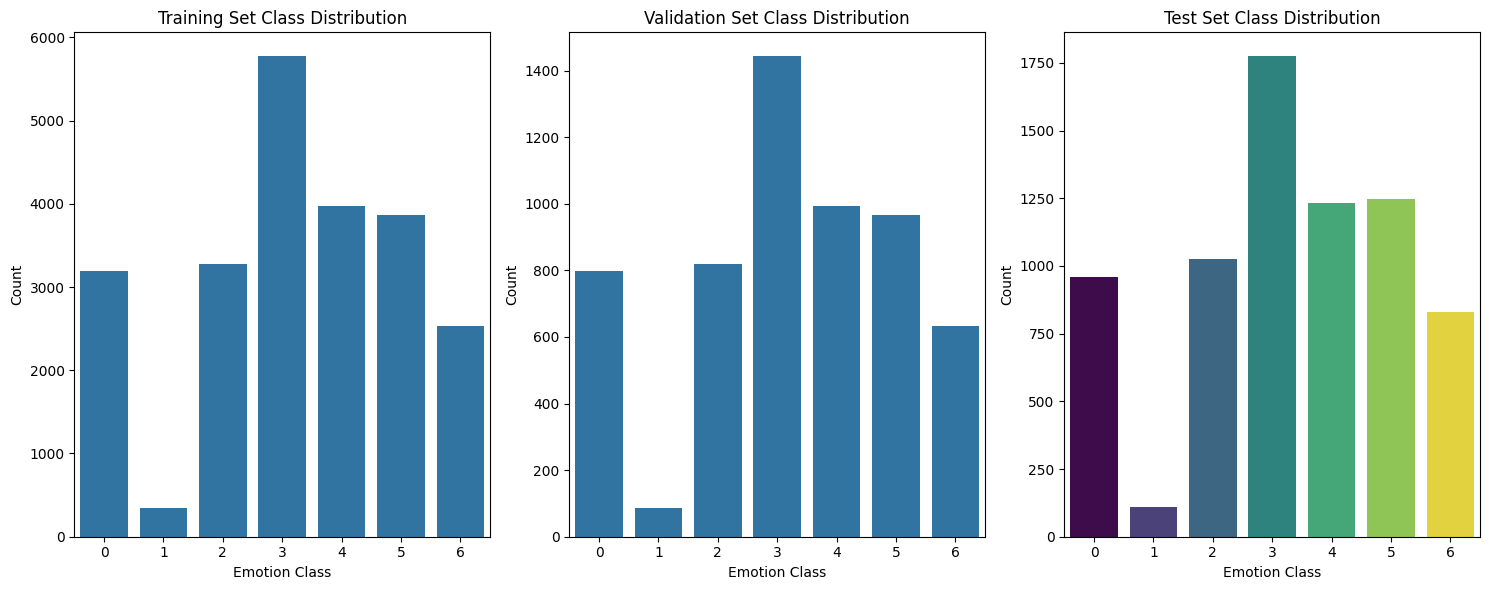

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.countplot(x='class', data=train_df)
plt.title('Training Set Class Distribution')
plt.xlabel('Emotion Class')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(x='class', data=val_df)
plt.title('Validation Set Class Distribution')
plt.xlabel('Emotion Class')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.countplot(x=test_generator.classes, hue=test_generator.classes, palette='viridis', legend=False)
plt.title('Test Set Class Distribution')
plt.xlabel('Emotion Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [17]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

# =============================
# PARAMETERS (from Custom VGGNet cell) for EDA context
# =============================
IMG_SIZE = 40   # paper used 40x40 crops
NUM_CLASSES = 7
BATCH_SIZE = 64

TRAIN_DIR = "/content/fer2013/train"
TEST_DIR  = "/content/fer2013/test"

# =============================
# LOAD FILES
# =============================
all_files, all_labels = [], []
classes = sorted(os.listdir(TRAIN_DIR))

for label, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    for file in os.listdir(class_path):
        all_files.append(os.path.join(class_path, file))
        all_labels.append(label)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

X_train, X_val, y_train, y_val = train_test_split(
    all_files, all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

train_df = pd.DataFrame({"filename": X_train, "class": y_train})
val_df   = pd.DataFrame({"filename": X_val, "class": y_val})

# =============================
# DATA AUGMENTATION (needed for generators)
# =============================
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(48,48),   # keep original size for cropping
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=1,
    shuffle=False
)

Found 22967 validated image filenames.
Found 5742 validated image filenames.
Found 7178 images belonging to 7 classes.


In [18]:
print("Train DataFrame Info:")
train_df.info()
print("\nTrain DataFrame Head:")
display(train_df.head())

print("\nValidation DataFrame Info:")
val_df.info()
print("\nValidation DataFrame Head:")
display(val_df.head())

print(f"\nNumber of test images: {test_generator.n}")

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22967 entries, 0 to 22966
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  22967 non-null  object
 1   class     22967 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 359.0+ KB

Train DataFrame Head:


,filename,class
0,/content/fer2013/train/fear/Training_36054963.jpg,2
1,/content/fer2013/train/fear/Training_24224842.jpg,2
2,/content/fer2013/train/angry/Training_68636162...,0
3,/content/fer2013/train/happy/Training_75285517...,3
4,/content/fer2013/train/neutral/Training_521398...,4



Validation DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5742 entries, 0 to 5741
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  5742 non-null   object
 1   class     5742 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.8+ KB

Validation DataFrame Head:


,filename,class
0,/content/fer2013/train/neutral/Training_189328...,4
1,/content/fer2013/train/sad/Training_40135555.jpg,5
2,/content/fer2013/train/disgust/Training_797210...,1
3,/content/fer2013/train/angry/Training_63203426...,0
4,/content/fer2013/train/fear/Training_79305631.jpg,2



Number of test images: 7178


### Sample Images

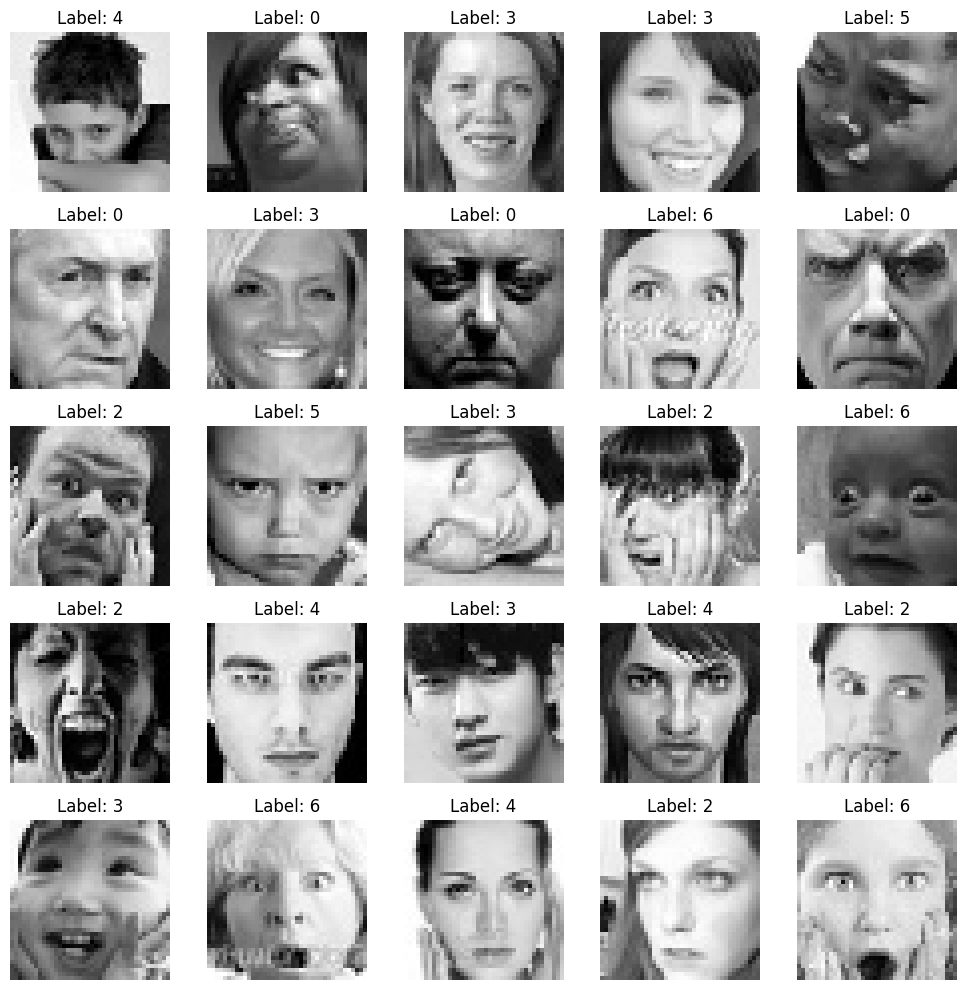

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    # Get a random image from the training set
    idx = np.random.randint(0, len(train_df))
    img_path = train_df.iloc[idx]['filename']
    label = train_df.iloc[idx]['class']

    img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    plt.imshow(img_array.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Class Distribution

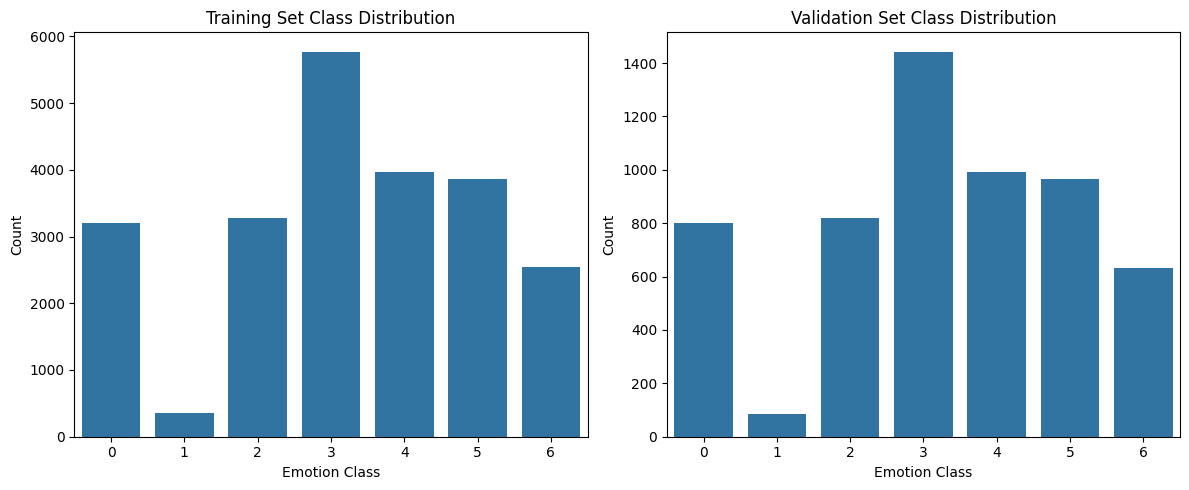

In [20]:
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='class', data=train_df)
plt.title('Training Set Class Distribution')
plt.xlabel('Emotion Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='class', data=val_df)
plt.title('Validation Set Class Distribution')
plt.xlabel('Emotion Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [25]:
balanced_dataframes = []
print("Initialized an empty list for balanced dataframes.")

Initialized an empty list for balanced dataframes.


In [26]:
TARGET_SAMPLES = 2500

for label in sorted(train_df['class'].unique()):
    class_df = train_df[train_df['class'] == label]

    if label == 1:  # Disgust class
        if len(class_df) < TARGET_SAMPLES:
            # Upsample disgust class
            upsample_count = TARGET_SAMPLES - len(class_df)
            upsampled_df = class_df.sample(upsample_count, replace=True, random_state=42)
            class_df = pd.concat([class_df, upsampled_df])
        print(f"Class {label} (Disgust): Upsampled to {len(class_df)} samples.")
    elif len(class_df) > TARGET_SAMPLES:
        # Downsample classes with more than TARGET_SAMPLES
        class_df = class_df.sample(TARGET_SAMPLES, random_state=42)
        print(f"Class {label}: Downsampled to {len(class_df)} samples.")
    else:
        print(f"Class {label}: Kept all {len(class_df)} samples.")

    balanced_dataframes.append(class_df)

# Concatenate all balanced dataframes and shuffle
train_df_balanced = pd.concat(balanced_dataframes).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balancing complete. Displaying info for train_df_balanced:")
train_df_balanced.info()
print("\nHead of train_df_balanced:")
display(train_df_balanced.head())

Class 0: Downsampled to 2500 samples.
Class 1 (Disgust): Upsampled to 2500 samples.
Class 2: Downsampled to 2500 samples.
Class 3: Downsampled to 2500 samples.
Class 4: Downsampled to 2500 samples.
Class 5: Downsampled to 2500 samples.
Class 6: Downsampled to 2500 samples.
Balancing complete. Displaying info for train_df_balanced:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  17500 non-null  object
 1   class     17500 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 273.6+ KB

Head of train_df_balanced:


,filename,class
0,/content/fer2013/train/angry/Training_59410566...,0
1,/content/fer2013/train/happy/Training_48076410...,3
2,/content/fer2013/train/disgust/Training_947885...,1
3,/content/fer2013/train/neutral/Training_907105...,4
4,/content/fer2013/train/disgust/Training_878995...,1


Found 17500 validated image filenames.
Updated train_generator_balanced with balanced data.


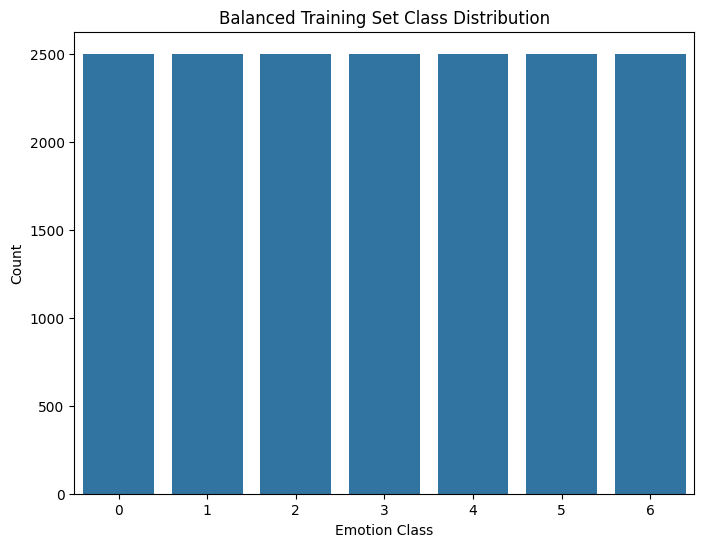

In [27]:
train_generator_balanced = train_datagen.flow_from_dataframe(
    train_df_balanced,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

print("Updated train_generator_balanced with balanced data.")


plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=train_df_balanced)
plt.title('Balanced Training Set Class Distribution')
plt.xlabel('Emotion Class')
plt.ylabel('Count')
plt.show()

## Summary:

### Q&A
The balancing operation was successfully completed, and the dataset is now ready for model training.

### Data Analysis Key Findings
*   The 'disgust' class (label 1), which initially had fewer samples, was successfully upsampled to 2500 samples.
*   Classes with more than 2500 samples (labels 0, 2, 3, 4, 5, and 6) were downsampled to 2500 samples each.
*   The `train_df_balanced` DataFrame now contains a total of 17,500 samples, with each of the 7 emotion classes having exactly 2500 samples.
*   The `train_generator` was successfully updated to `train_generator_balanced` using the new balanced dataset, which found all 17,500 validated image filenames.
*   Visual inspection of the class distribution confirmed an equal count of approximately 2500 samples for every emotion class.

### Insights or Next Steps
*   The balanced dataset addresses potential class imbalance issues, which should lead to a more robust and fair model performance across all emotion categories during training.
*   Proceed with training the model using the `train_generator_balanced` to leverage the now balanced training data.


In [40]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Necessary libraries imported.")

Necessary libraries imported.


In [41]:
IMG_SIZE = 48
BATCH_SIZE = 64
NUM_CLASSES = 7

TRAIN_DIR = "/content/fer2013/train"
TEST_DIR  = "/content/fer2013/test"

print(f"Parameters set: IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, NUM_CLASSES={NUM_CLASSES}")
print(f"Data directories: TRAIN_DIR='{TRAIN_DIR}', TEST_DIR='{TEST_DIR}'")

# Load file paths and labels
all_files = []
all_labels = []

classes = sorted(os.listdir(TRAIN_DIR))

for label, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    for file in os.listdir(class_path):
        all_files.append(os.path.join(class_path, file))
        all_labels.append(label)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

print(f"Loaded {len(all_files)} total image files and labels.")

# Split train into train + val
X_train, X_val, y_train, y_val = train_test_split(
    all_files, all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=42
)

train_df = pd.DataFrame({"filename": X_train, "class": y_train})
val_df   = pd.DataFrame({"filename": X_val, "class": y_val})

print(f"Train set: {len(train_df)} samples, Validation set: {len(val_df)} samples.")

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data generators created successfully for VGG16.")

Parameters set: IMG_SIZE=48, BATCH_SIZE=64, NUM_CLASSES=7
Data directories: TRAIN_DIR='/content/fer2013/train', TEST_DIR='/content/fer2013/test'
Loaded 28709 total image files and labels.
Train set: 22967 samples, Validation set: 5742 samples.
Found 22967 validated image filenames.
Found 5742 validated image filenames.
Found 7178 images belonging to 7 classes.
Data generators created successfully for VGG16.



Load the VGG16 model pre-trained on 'imagenet' with `include_top=False` and set `base_model.trainable = False`. Add a custom classification head (Flatten, Dense with 512 units and l2 regularization, Dropout, and final Dense with 7 units and softmax activation). Compile the model with SGD optimizer (learning_rate=0.01, momentum=0.9, nesterov=True), 'sparse_categorical_crossentropy' loss, and 'accuracy' metric.


In [42]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import SGD

print("Necessary Keras components imported.")

Necessary Keras components imported.


In [43]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

optimizer = SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("VGG16 model with frozen base and custom head built and compiled.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,935 (57.15 MB)

 Trainable params: 266,247 (1.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

VGG16 model with frozen base and custom head built and compiled.



Now that the VGG16 model is built and compiled, I will define the callbacks required for training, including `EarlyStopping` to prevent overfitting, `ReduceLROnPlateau` to adjust the learning rate, and `ModelCheckpoint` to save the best performing model. These callbacks will be used in the subsequent training step.



In [44]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.75,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_pretrained_vgg16.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) defined.")

Callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint) defined.


Now that the VGG16 model with a frozen base and custom head is compiled, and the callbacks are defined, I will proceed with the initial training of the model using the `train_generator` and `val_generator`. The defined callbacks will monitor performance and save the best model weights.



In [45]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

print("Initial training with frozen VGG16 base complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2542 - loss: 1.8675
Epoch 1: val_accuracy improved from -inf to 0.31017, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - accuracy: 0.2542 - loss: 1.8674 - val_accuracy: 0.3102 - val_loss: 1.7405 - learning_rate: 0.0100
Epoch 2/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2929 - loss: 1.7794
Epoch 2: val_accuracy improved from 0.31017 to 0.33682, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.2929 - loss: 1.7794 - val_accuracy: 0.3368 - val_loss: 1.7033 - learning_rate: 0.0100
Epoch 3/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3033 - loss: 1.7703
Epoch 3: val_accuracy improved from 0.33682 to 0.34622, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.3033 - loss: 1.7703 - val_accuracy: 0.3462 - val_loss: 1.7018 - learning_rate: 0.0100
Epoch 4/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3083 - loss: 1.7578
Epoch 4: val_accuracy did not improve from 0.34622
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.3083 - loss: 1.7579 - val_accuracy: 0.3379 - val_loss: 1.6941 - learning_rate: 0.0100
Epoch 5/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3112 - loss: 1.7545
Epoch 5: val_accuracy did not improve from 0.34622
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.3112 - loss: 1.7545 - val_accuracy: 0.3272 - val_loss: 1.7029 - learning_rate: 0.0100
Epoch 6/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3167 - loss: 1.7495
Epoch 6: val_accuracy improved from 0.34622 to 0.35441, saving model to best_pretrained_vgg16.h5


...

359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.3455 - loss: 1.6939 - val_accuracy: 0.3945 - val_loss: 1.6140 - learning_rate: 0.0056
Epoch 25/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3423 - loss: 1.6920
Epoch 25: val_accuracy did not improve from 0.39446
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.3423 - loss: 1.6920 - val_accuracy: 0.3849 - val_loss: 1.6140 - learning_rate: 0.0056
Epoch 26/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3450 - loss: 1.6891
Epoch 26: val_accuracy improved from 0.39446 to 0.39951, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.3450 - loss: 1.6891 - val_accuracy: 0.3995 - val_loss: 1.6043 - learning_rate: 0.0056
Epoch 27/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3429 - loss: 1.6917
Epoch 27: val_accuracy did not improve from 0.39951
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.3429 - loss: 1.6917 - val_accuracy: 0.3922 - val_loss: 1.6071 - learning_rate: 0.0056
Epoch 28/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3399 - loss: 1.7006
Epoch 28: val_accuracy did not improve from 0.39951
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.3400 - loss: 1.7006 - val_accuracy: 0.3826 - val_loss: 1.6140 - learning_rate: 0.0056
Epoch 29/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3512 - loss: 1.6826
Epoch 29: val_accuracy did not improve from 0.39951
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.3512 - loss: 1.6826 - val_accuracy: 0.3887 - val_loss: 1.6138 - learning_rate: 0.0056
Epoch

359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.3543 - loss: 1.6717 - val_accuracy: 0.3997 - val_loss: 1.5941 - learning_rate: 0.0032
Epoch 39/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3561 - loss: 1.6679
Epoch 39: val_accuracy improved from 0.39969 to 0.40334, saving model to best_pretrained_vgg16.h5


359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.3561 - loss: 1.6679 - val_accuracy: 0.4033 - val_loss: 1.5924 - learning_rate: 0.0032
Epoch 40/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3544 - loss: 1.6741
Epoch 40: val_accuracy did not improve from 0.40334
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.3544 - loss: 1.6741 - val_accuracy: 0.3920 - val_loss: 1.6005 - learning_rate: 0.0032
Epoch 41/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3583 - loss: 1.6583
Epoch 41: val_accuracy did not improve from 0.40334
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.3583 - loss: 1.6583 - val_accuracy: 0.3990 - val_loss: 1.5958 - learning_rate: 0.0032
Epoch 42/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3514 - loss: 1.6748
Epoch 42: val_accuracy did not improve from 0.40334
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.3515 - loss: 1.6748 - val_accuracy: 0.3929 - val_loss: 1.5960 - learning_rate: 0.0032
Epoch

359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.3623 - loss: 1.6588 - val_accuracy: 0.4108 - val_loss: 1.5823 - learning_rate: 0.0024
Epoch 47/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3599 - loss: 1.6566
Epoch 47: val_accuracy did not improve from 0.41083
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.3599 - loss: 1.6566 - val_accuracy: 0.3885 - val_loss: 1.6010 - learning_rate: 0.0024
Epoch 48/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3562 - loss: 1.6667
Epoch 48: val_accuracy did not improve from 0.41083
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.3562 - loss: 1.6667 - val_accuracy: 0.3960 - val_loss: 1.5993 - learning_rate: 0.0024
Epoch 49/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3647 - loss: 1.6597
Epoch 49: val_accuracy did not improve from 0.41083
359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.3647 - loss: 1.6597 - val_accuracy: 0.3992 - val_loss: 1.5869 - learning_rate: 0.0024
Epoch